# Homework 4 - implementing iterative methods

In [1]:
#imports
import matplotlib.pyplot as plt
import numpy as np

### Jacobi method

In [2]:
def jacobi(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    errors=[] # added error to be tracked and returned
    
    for k in range(max_iterations):
        x_new = np.zeros_like(x)
        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]

        # Check for convergence
        errors.append(np.linalg.norm(x_new - x, ord=np.inf))# add it to the errror tracking array
        if np.linalg.norm(x_new - x, ord=np.inf) < tol:
            return x_new, k, errors
        x = x_new
    return x, max_iterations,errors

### Gauss-seidel

In [3]:
def gauss_seidel(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    errors=[] # added error to be tracked and returned
    
    for k in range(max_iterations):
        x_new = x.copy()
        for i in range(n):
            s1 = sum(A[i][j] * x_new[j] for j in range(i)) # Using already updated values
            s2 = sum(A[i][j] * x[j] for j in range(i + 1, n)) # Using old values
            x_new[i] = (b[i] - s1 - s2) / A[i][i]
            
        errors.append(np.linalg.norm(x_new - x, ord=np.inf)) # add it to the errror tracking away
        # Check for convergence
        if np.linalg.norm(x_new - x, ord=np.inf) < tol:
            return x_new, k, errors
        x = x_new
    return x, max_iterations, errors

set up

method: Gauss Seidel - tol: 0.001
iterations:  3
solution:  [ 3.00000035 -2.50000004  6.99999999]

method: Gauss Seidel - tol: 1e-06
iterations:  4
solution:  [ 3.  -2.5  7. ]

method: Gauss Seidel - tol: 1e-09
iterations:  6
solution:  [ 3.  -2.5  7. ]

method: Jacobi - tol: 0.001
iterations:  3
solution:  [ 3.0000225  -2.50000266  6.99998104]

method: Jacobi - tol: 1e-06
iterations:  6
solution:  [ 3.  -2.5  7. ]

method: Jacobi - tol: 1e-09
iterations:  8
solution:  [ 3.  -2.5  7. ]



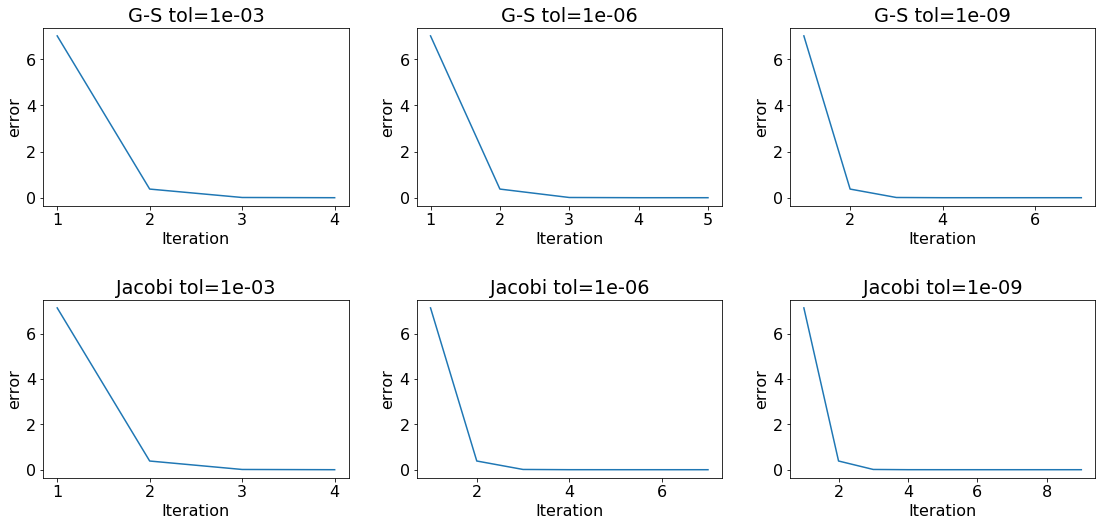

In [4]:
#initiaize varible 
A = np.array([[3,-.1,-.2],
              [.1,7,-.3],
              [.3,-.2,10]])
b = np.array([7.85,-19.3,71.4])
x0 = np.zeros_like(b)
max_iterations = 100
tols = np.array([1e-3,1e-6,1e-9])

plt.figure(figsize=(16, 8)) # had to google how to make the plots bigger so they are more readable
plt.rcParams.update({"font.size": 16}) 
# making a subpot with the top row the output for gauss seidel output at differnt tolerances
for i in range(tols.size):
    print("method: Gauss Seidel - tol:", tols[i])
    plt.subplot(2,3,i+1)
    
    solution, iterations, error = gauss_seidel(A, b, x0, tols[i], max_iterations)
    print("iterations: ", iterations)
    print("solution: ", solution)
    print()
    
    #plotting the out put
    x=np.arange(1,len(error)+1)
    plt.plot(x, error)
    plt.title(f"G-S tol={tols[i]:.0e}") 
    plt.xlabel("Iteration")
    plt.ylabel("error")

    
#repeating the same  flow but for jacobi in the seconf row
for i in range(tols.size):
    print("method: Jacobi - tol:", tols[i])
    plt.subplot(2,3,i+4)
    
    solution, iterations, error = jacobi(A, b, x0, tols[i], max_iterations)
    print("iterations: ", iterations)
    print("solution: ", solution)
    print()
    
    x=np.arange(1,len(error)+1)
    plt.plot(x, error)
    plt.title(f"Jacobi tol={tols[i]:.0e}") 
    plt.xlabel("Iteration")
    plt.ylabel("error")


plt.tight_layout(pad=2.0)
    

notes: 
- The curve should generally decrease toward 0 as the method converges
- jacobis method took more iterations to converge, expecially for the smaller tolerances. 
- the larger the tolerance the quicker the solution is found for both methods becuase the window of how close the error needs to be is big. 
- smaller tolerance the slower it converges becuase the required error needs to be much smaller